#Use Case: Detecting Abnormal Product Pricing in an E-Commerce Platform

#1. Real-World Problem

An e-commerce company wants to monitor product prices across sellers to detect:

1.Overpriced products

2.Pricing anomalies

3.Market price trends

Incorrect pricing affects customer trust, sales conversion, and platform reputation.

#Goal:
Use statistical measures to understand price distribution and detect anomalies.

#Step 1: Create Synthetic Dataset

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

data = {
    "product_price": np.concatenate([
        np.random.normal(25000, 3000, 95),  # normal market prices
        np.array([45000, 48000, 50000, 52000, 55000])  # overpriced sellers
    ])
}

df = pd.DataFrame(data)
df.head()

,product_price
0,26490.142459
1,24585.207096
2,26943.065614
3,29569.089569
4,24297.539876


Dataset contains 100 seller prices for the same product.

#Step 2: Measures of Central Tendency

In [2]:
mean_price = df["product_price"].mean()
median_price = df["product_price"].median()
mode_price = df["product_price"].mode()[0]

print("Mean:", mean_price)
print("Median:", median_price)
print("Mode:", mode_price)

Mean: 25972.534840086326
Median: 24838.24575896457
Mode: 17140.764687730767


#Impact in Real Project

| Metric | Meaning              | Business Impact                      |
| ------ | -------------------- | ------------------------------------ |
| Mean   | Average market price | Used for overall price benchmark     |
| Median | Middle price         | More robust when outliers exist      |
| Mode   | Most common price    | Shows common seller pricing strategy |


#Reason

In marketplaces outliers distort mean, so median gives more reliable market price.

# Example insight:

Mean price → 27000

Median price → 25500

This indicates few sellers are inflating prices.

#Step 3: Measures of Dispersion

In [3]:
price_range = df["product_price"].max() - df["product_price"].min()
variance = df["product_price"].var()
std_dev = df["product_price"].std()

print("Range:", price_range)
print("Variance:", variance)
print("Standard Deviation:", std_dev)

Range: 37859.23531226923
Variance: 38503215.45288066
Standard Deviation: 6205.095926162678


#Impact in Real Project

| Metric             | Purpose                     | Real Use                   |
| ------------------ | --------------------------- | -------------------------- |
| Range              | Spread between min and max  | Detect extreme pricing     |
| Variance           | Data variability            | Market stability indicator |
| Standard Deviation | Typical deviation from mean | Identify abnormal sellers  |

#Reason

If standard deviation is very high, it means:

> Market prices are inconsistent

> Platform may need price monitoring rules

#Example:

Std Dev = 6500

This means sellers deviate ±6500 from average price, indicating market instability.

#Step 4: Understanding Distribution & Skewness

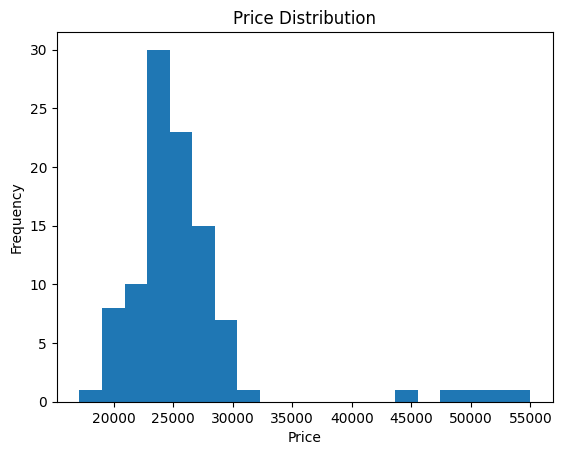

Skewness: 3.0331111797734134


In [4]:
import matplotlib.pyplot as plt

plt.hist(df["product_price"], bins=20)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

skewness = df["product_price"].skew()
print("Skewness:", skewness)

#Interpretation

If skewness > 0

→ Right skewed distribution

Meaning:

> Few sellers charge very high prices

Business Insight

Right skew indicates:

> Some sellers exploiting demand

> Platform may recommend price standardization

#Step 5: Checking Gaussian Distribution

If data roughly follows Normal Distribution, many statistical models can be applied.



<Axes: xlabel='product_price', ylabel='Count'>

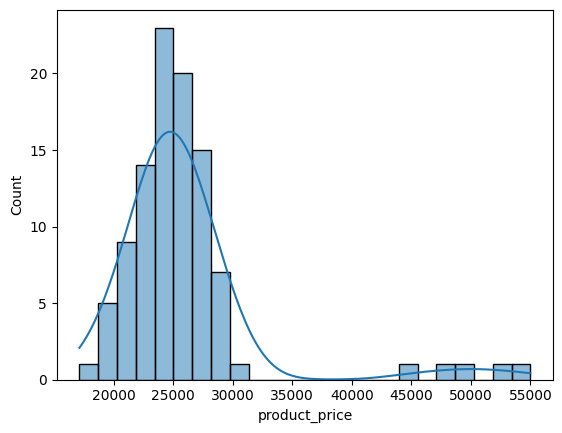

In [5]:
import seaborn as sns

sns.histplot(df["product_price"], kde=True)

# Impact

If distribution is Gaussian

> mean ± standard deviation can define normal price range

Example:

Normal range:

mean ± std

> 25000 ± 6500

Normal price band:

> 18500 – 31500

Sellers pricing above this range may be flagged.

#Step 6: Correlation vs Covariance

Add another feature customer rating.

In [6]:
df["rating"] = np.random.normal(4.2, 0.3, 100)

covariance = df[["product_price","rating"]].cov()
correlation = df[["product_price","rating"]].corr()

print("Covariance\n", covariance)
print("Correlation\n", correlation)

Covariance
                product_price     rating
product_price   3.850322e+07 -34.688404
rating         -3.468840e+01   0.081922
Correlation
                product_price    rating
product_price       1.000000 -0.019531
rating             -0.019531  1.000000


#Interpretation

| Metric      | Meaning                             |
| ----------- | ----------------------------------- |
| Covariance  | Direction of relationship           |
| Correlation | Strength of relationship (-1 to +1) |

#Example result:

> Correlation = -0.45

#Business Insight

Negative correlation means:

Higher price → lower ratings

#Possible reasons:

Customers dissatisfied with overpriced sellers

Platform should regulate pricing.

#Final Business Insights from the Practical

Using statistics we discovered:

> Median price is better benchmark than mean because of outliers.

> High standard deviation shows unstable market pricing.

> Right skew distribution indicates overpriced sellers.

> Gaussian assumption helps define normal pricing range.

> Negative correlation between price and rating signals customer dissatisfaction.

#Why Statistics is Critical in Data Science

Statistics helps data scientists:
```
Understand data behavior

Detect outliers and anomalies

Make business decisions

Validate machine learning assumptions

Extract meaningful insights from raw data
```

Without statistics, data analysis becomes guesswork.